In [38]:
from google.colab import files

uploaded = files.upload()

Saving annual_metropolitan_train_station_entries_fy_2018_2019.csv to annual_metropolitan_train_station_entries_fy_2018_2019.csv
Saving annual_metropolitan_train_station_entries_fy_2019_2020.csv to annual_metropolitan_train_station_entries_fy_2019_2020.csv
Saving annual_metropolitan_train_station_entries_fy_2020_2021.csv to annual_metropolitan_train_station_entries_fy_2020_2021.csv
Saving annual_metropolitan_train_station_entries_fy_2021_2022.csv to annual_metropolitan_train_station_entries_fy_2021_2022.csv
Saving annual_metropolitan_train_station_entries_fy_2022_2023.csv to annual_metropolitan_train_station_entries_fy_2022_2023.csv
Saving annual_metropolitan_train_station_entries_fy_2023_2024.csv to annual_metropolitan_train_station_entries_fy_2023_2024.csv
Saving annual_metropolitan_train_station_entries_fy_2024_2025.csv to annual_metropolitan_train_station_entries_fy_2024_2025 (2).csv
Saving annual_regional_train_station_entries_fy_2018_2019.csv to annual_regional_train_station_entri

In [54]:
import os
print(os.listdir())

['.config', 'annual_regional_train_station_entries_fy_2024_2025 (2).csv', 'annual_metropolitan_train_station_entries_fy_2023_2024.csv', 'annual_regional_train_station_entries_fy_2018_2019.csv', 'annual_metropolitan_train_station_entries_fy_2024_2025 (2).csv', 'annual_metropolitan_train_station_entries_fy_2018_2019.csv', 'annual_regional_train_station_entries_fy_2024_2025.csv', 'annual_metropolitan_train_station_entries_fy_2024_2025 (1).csv', 'annual_metropolitan_train_station_entries_fy_2022_2023.csv', 'annual_regional_train_station_entries_fy_2020_2021.csv', 'annual_regional_train_station_entries_fy_2021_2022.csv', 'annual_regional_train_station_entries_fy_2019_2020.csv', 'annual_regional_train_station_entries_fy_2022_2023.csv', 'annual_metropolitan_train_station_entries_fy_2021_2022.csv', 'annual_metropolitan_train_station_entries_fy_2019_2020.csv', 'annual_metropolitan_train_station_entries_fy_2024_2025.csv', 'annual_metropolitan_train_station_entries_fy_2020_2021.csv', 'annual_regi

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# Financial years in correct chronological order
# ---------------------------------------------------------
YEAR_ORDER = [
    "FY18-19",
    "FY19-20",
    "FY20-21",
    "FY21-22",
    "FY22-23",
    "FY23-24",
    "FY24-25"
]

# ---------------------------------------------------------
# Metropolitan files
# ---------------------------------------------------------
metro_files = {
    "FY18-19": "annual_metropolitan_train_station_entries_fy_2018_2019.csv",
    "FY19-20": "annual_metropolitan_train_station_entries_fy_2019_2020.csv",
    "FY20-21": "annual_metropolitan_train_station_entries_fy_2020_2021.csv",
    "FY21-22": "annual_metropolitan_train_station_entries_fy_2021_2022.csv",
    "FY22-23": "annual_metropolitan_train_station_entries_fy_2022_2023.csv",
    "FY23-24": "annual_metropolitan_train_station_entries_fy_2023_2024.csv",
    "FY24-25": "annual_metropolitan_train_station_entries_fy_2024_2025.csv"
}

# ---------------------------------------------------------
# Regional files
# ---------------------------------------------------------
regional_files = {
    "FY18-19": "annual_regional_train_station_entries_fy_2018_2019.csv",
    "FY19-20": "annual_regional_train_station_entries_fy_2019_2020.csv",
    "FY20-21": "annual_regional_train_station_entries_fy_2020_2021.csv",
    "FY21-22": "annual_regional_train_station_entries_fy_2021_2022.csv",
    "FY22-23": "annual_regional_train_station_entries_fy_2022_2023.csv",
    "FY23-24": "annual_regional_train_station_entries_fy_2023_2024.csv",
    "FY24-25": "annual_regional_train_station_entries_fy_2024_2025.csv"
}

# ---------------------------------------------------------
# Function to load and combine yearly datasets
# ---------------------------------------------------------
def load_multiple_years(file_dict):
    frames = []

    for year, filename in file_dict.items():

        if not os.path.exists(filename):
            print(f"WARNING: File not found: {filename}")
            continue

        df = pd.read_csv(filename)

        # Remove spaces from column names
        df.columns = df.columns.str.strip()

        # Force correct financial year
        # This avoids differences in year formatting between files
        df["Fin_year"] = year

        # Keep source filename for traceability
        df["Source_File"] = filename

        frames.append(df)

    if len(frames) == 0:
        raise ValueError("No files were loaded.")

    return pd.concat(frames, ignore_index=True, sort=False)


# Combine all years
metro = load_multiple_years(metro_files)
regional = load_multiple_years(regional_files)

print("Files successfully combined.")
print("Metro combined shape:", metro.shape)
print("Regional combined shape:", regional.shape)

Files successfully combined.
Metro combined shape: (1555, 17)
Regional combined shape: (646, 7)


In [56]:
# ---------------------------------------------------------
# Clean metropolitan dataset
# ---------------------------------------------------------

metro.columns = metro.columns.str.strip()

metro["Stop_ID"] = pd.to_numeric(
    metro["Stop_ID"],
    errors="coerce"
).astype("Int64")

metro["Pax_annual"] = pd.to_numeric(
    metro["Pax_annual"],
    errors="coerce"
)

metro["Stop_lat"] = pd.to_numeric(
    metro["Stop_lat"],
    errors="coerce"
)

metro["Stop_long"] = pd.to_numeric(
    metro["Stop_long"],
    errors="coerce"
)

metro["Stop_name"] = (
    metro["Stop_name"]
    .astype(str)
    .str.strip()
)

metro["Stop_name_clean"] = (
    metro["Stop_name"]
    .str.upper()
    .str.strip()
)


# ---------------------------------------------------------
# Clean regional dataset
# ---------------------------------------------------------

regional.columns = regional.columns.str.strip()

regional["Stop_ID"] = pd.to_numeric(
    regional["Stop_ID"],
    errors="coerce"
).astype("Int64")

regional["Pax_annual"] = pd.to_numeric(
    regional["Pax_annual"],
    errors="coerce"
)

regional["Stop_lat"] = pd.to_numeric(
    regional["Stop_lat"],
    errors="coerce"
)

regional["Stop_long"] = pd.to_numeric(
    regional["Stop_long"],
    errors="coerce"
)

regional["Stop_name"] = (
    regional["Stop_name"]
    .astype(str)
    .str.strip()
)

regional["Stop_name_clean"] = (
    regional["Stop_name"]
    .str.upper()
    .str.strip()
)


# ---------------------------------------------------------
# Create numeric year order for sorting
# ---------------------------------------------------------

year_number = {
    year: i
    for i, year in enumerate(YEAR_ORDER)
}

metro["Year_order"] = metro["Fin_year"].map(year_number)
regional["Year_order"] = regional["Fin_year"].map(year_number)

print("Cleaning complete.")

Cleaning complete.


In [57]:
print("METROPOLITAN YEARS")
print(
    metro["Fin_year"]
    .value_counts()
    .reindex(YEAR_ORDER)
)

print("\nREGIONAL YEARS")
print(
    regional["Fin_year"]
    .value_counts()
    .reindex(YEAR_ORDER)
)

print("\nNumber of Metro years:",
      metro["Fin_year"].nunique())

print("Number of Regional years:",
      regional["Fin_year"].nunique())

METROPOLITAN YEARS
Fin_year
FY18-19    222
FY19-20    222
FY20-21    222
FY21-22    222
FY22-23    223
FY23-24    222
FY24-25    222
Name: count, dtype: int64

REGIONAL YEARS
Fin_year
FY18-19    90
FY19-20    91
FY20-21    91
FY21-22    92
FY22-23    94
FY23-24    94
FY24-25    94
Name: count, dtype: int64

Number of Metro years: 7
Number of Regional years: 7


In [58]:
print("=" * 60)
print("METROPOLITAN DATA")
print("=" * 60)

print("Shape:", metro.shape)

print("\nColumns:")
print(metro.columns.tolist())

print("\nData types:")
print(metro.dtypes)

print("\nUnique financial years:")
print(sorted(
    metro["Fin_year"].dropna().unique(),
    key=lambda x: YEAR_ORDER.index(x)
))

print("\nUnique stations:")
print(metro["Stop_ID"].nunique())


print("\n" + "=" * 60)
print("REGIONAL DATA")
print("=" * 60)

print("Shape:", regional.shape)

print("\nColumns:")
print(regional.columns.tolist())

print("\nData types:")
print(regional.dtypes)

print("\nUnique financial years:")
print(sorted(
    regional["Fin_year"].dropna().unique(),
    key=lambda x: YEAR_ORDER.index(x)
))

print("\nUnique stations:")
print(regional["Stop_ID"].nunique())

METROPOLITAN DATA
Shape: (1555, 19)

Columns:
['Fin_year', 'Stop_ID', 'Stop_name', 'Stop_lat', 'Stop_long', 'Pax_annual', 'Pax_weekday', 'Pax_norm_weekday', 'Pax_sch_hol_weekday', 'Pax_Saturday', 'Pax_Sunday', 'Pax_pre_AM_peak', 'Pax_AM_peak', 'Pax_interpeak', 'Pax_PM_peak', 'Pax_PM_late', 'Source_File', 'Stop_name_clean', 'Year_order']

Data types:
Fin_year                object
Stop_ID                  Int64
Stop_name               object
Stop_lat               float64
Stop_long              float64
Pax_annual               int64
Pax_weekday              int64
Pax_norm_weekday         int64
Pax_sch_hol_weekday      int64
Pax_Saturday             int64
Pax_Sunday               int64
Pax_pre_AM_peak          int64
Pax_AM_peak              int64
Pax_interpeak            int64
Pax_PM_peak              int64
Pax_PM_late              int64
Source_File             object
Stop_name_clean         object
Year_order               int64
dtype: object

Unique financial years:
['FY18-19', 'FY19-20

In [59]:
metro_station_coverage = (
    metro
    .groupby("Fin_year")["Stop_ID"]
    .nunique()
    .reindex(YEAR_ORDER)
    .reset_index(name="Number_of_stations")
)

regional_station_coverage = (
    regional
    .groupby("Fin_year")["Stop_ID"]
    .nunique()
    .reindex(YEAR_ORDER)
    .reset_index(name="Number_of_stations")
)

print("METROPOLITAN STATION COVERAGE")
display(metro_station_coverage)

print("\nREGIONAL STATION COVERAGE")
display(regional_station_coverage)

METROPOLITAN STATION COVERAGE


,Fin_year,Number_of_stations
0,FY18-19,222
1,FY19-20,222
2,FY20-21,222
3,FY21-22,222
4,FY22-23,223
5,FY23-24,222
6,FY24-25,222



REGIONAL STATION COVERAGE


,Fin_year,Number_of_stations
0,FY18-19,90
1,FY19-20,91
2,FY20-21,91
3,FY21-22,92
4,FY22-23,94
5,FY23-24,94
6,FY24-25,94


In [60]:
metro_missing = pd.DataFrame({
    "Missing": metro.isnull().sum(),
    "Missing_Percent":
        metro.isnull().mean() * 100
}).sort_values(
    "Missing_Percent",
    ascending=False
)

regional_missing = pd.DataFrame({
    "Missing": regional.isnull().sum(),
    "Missing_Percent":
        regional.isnull().mean() * 100
}).sort_values(
    "Missing_Percent",
    ascending=False
)

print("METROPOLITAN MISSING VALUES")
display(metro_missing)

print("\nREGIONAL MISSING VALUES")
display(regional_missing)

METROPOLITAN MISSING VALUES


,Missing,Missing_Percent
Fin_year,0,0.0
Stop_ID,0,0.0
Stop_name,0,0.0
Stop_lat,0,0.0
Stop_long,0,0.0
Pax_annual,0,0.0
Pax_weekday,0,0.0
Pax_norm_weekday,0,0.0
Pax_sch_hol_weekday,0,0.0
Pax_Saturday,0,0.0



REGIONAL MISSING VALUES


,Missing,Missing_Percent
Fin_year,0,0.0
Stop_ID,0,0.0
Stop_name,0,0.0
Stop_lat,0,0.0
Stop_long,0,0.0
Pax_annual,0,0.0
Source_File,0,0.0
Stop_name_clean,0,0.0
Year_order,0,0.0


In [61]:
key_columns = [
    "Fin_year",
    "Stop_ID",
    "Stop_name",
    "Pax_annual"
]

print("METRO - MISSING KEY VARIABLES")
display(
    metro[key_columns]
    .isnull()
    .sum()
    .to_frame("Missing")
)

print("\nREGIONAL - MISSING KEY VARIABLES")
display(
    regional[key_columns]
    .isnull()
    .sum()
    .to_frame("Missing")
)

METRO - MISSING KEY VARIABLES


,Missing
Fin_year,0
Stop_ID,0
Stop_name,0
Pax_annual,0



REGIONAL - MISSING KEY VARIABLES


,Missing
Fin_year,0
Stop_ID,0
Stop_name,0
Pax_annual,0


In [62]:
metro_exact_duplicates = (
    metro
    .drop(columns=["Source_File"], errors="ignore")
    .duplicated()
    .sum()
)

regional_exact_duplicates = (
    regional
    .drop(columns=["Source_File"], errors="ignore")
    .duplicated()
    .sum()
)

metro_station_year_duplicates = (
    metro
    .duplicated(
        subset=["Fin_year", "Stop_ID"],
        keep=False
    )
)

regional_station_year_duplicates = (
    regional
    .duplicated(
        subset=["Fin_year", "Stop_ID"],
        keep=False
    )
)

print("Metro exact duplicate rows:",
      metro_exact_duplicates)

print("Regional exact duplicate rows:",
      regional_exact_duplicates)

print(
    "Metro duplicate station-year records:",
    metro_station_year_duplicates.sum()
)

print(
    "Regional duplicate station-year records:",
    regional_station_year_duplicates.sum()
)

Metro exact duplicate rows: 0
Regional exact duplicate rows: 0
Metro duplicate station-year records: 0
Regional duplicate station-year records: 0


In [64]:
if metro_station_year_duplicates.any():
    print("\nMETRO DUPLICATE STATION-YEAR RECORDS")
    display(
        metro.loc[
            metro_station_year_duplicates,
            [
                "Fin_year",
                "Stop_ID",
                "Stop_name",
                "Pax_annual",
                "Source_File"
            ]
        ].sort_values(
            ["Stop_ID", "Year_order"]
        )
    )

if regional_station_year_duplicates.any():
    print("\nREGIONAL DUPLICATE STATION-YEAR RECORDS")
    display(
        regional.loc[
            regional_station_year_duplicates,
            [
                "Fin_year",
                "Stop_ID",
                "Stop_name",
                "Pax_annual",
                "Source_File"
            ]
        ].sort_values(
            ["Stop_ID", "Year_order"]
        )
    )

In [65]:
metro_id_name = (
    metro
    .groupby("Stop_ID")
    .agg(
        Number_of_names=(
            "Stop_name_clean",
            "nunique"
        ),
        Names=(
            "Stop_name_clean",
            lambda x:
                sorted(set(x))
        )
    )
)

metro_id_name_conflicts = (
    metro_id_name[
        metro_id_name["Number_of_names"] > 1
    ]
)

print("METRO IDs WITH MULTIPLE NAMES")
display(metro_id_name_conflicts)

METRO IDs WITH MULTIPLE NAMES


,Number_of_names,Names
Stop_ID,,


In [66]:
regional_id_name = (
    regional
    .groupby("Stop_ID")
    .agg(
        Number_of_names=(
            "Stop_name_clean",
            "nunique"
        ),
        Names=(
            "Stop_name_clean",
            lambda x:
                sorted(set(x))
        )
    )
)

regional_id_name_conflicts = (
    regional_id_name[
        regional_id_name["Number_of_names"] > 1
    ]
)

print("REGIONAL IDs WITH MULTIPLE NAMES")
display(regional_id_name_conflicts)

REGIONAL IDs WITH MULTIPLE NAMES


,Number_of_names,Names
Stop_ID,,
19980,2,"[MELTON, MELTON RAILWAY STATION (MELTON SOUTH)]"
19981,2,"[ROCKBANK, ROCKBANK RAILWAY STATION (ROCKBANK)]"
19982,2,"[DEER PARK, DEER PARK RAILWAY STATION (DEER PA..."
20020,2,"[ARDEER, ARDEER RAILWAY STATION (ARDEER)]"
20287,2,"[ALBURY, ALBURY RAILWAY STATION (ALBURY (NSW))]"
...,...,...
48804,2,"[COBBLEBANK, COBBLEBANK RAILWAY STATION (COBBL..."
49295,2,"[RAYWOOD, RAYWOOD RAILWAY STATION (RAYWOOD)]"
49296,2,"[HUNTLY, HUNTLY RAILWAY STATION (HUNTLY)]"


In [67]:
metro_name_id = (
    metro
    .groupby("Stop_name_clean")
    .agg(
        Number_of_IDs=(
            "Stop_ID",
            "nunique"
        ),
        IDs=(
            "Stop_ID",
            lambda x:
                sorted(
                    set(x.dropna())
                )
        )
    )
)

metro_name_id_conflicts = (
    metro_name_id[
        metro_name_id["Number_of_IDs"] > 1
    ]
)

print("METRO NAMES WITH MULTIPLE IDs")
display(metro_name_id_conflicts)

METRO NAMES WITH MULTIPLE IDs


,Number_of_IDs,IDs
Stop_name_clean,,


In [68]:
regional_name_id = (
    regional
    .groupby("Stop_name_clean")
    .agg(
        Number_of_IDs=(
            "Stop_ID",
            "nunique"
        ),
        IDs=(
            "Stop_ID",
            lambda x:
                sorted(
                    set(x.dropna())
                )
        )
    )
)

regional_name_id_conflicts = (
    regional_name_id[
        regional_name_id["Number_of_IDs"] > 1
    ]
)

print("REGIONAL NAMES WITH MULTIPLE IDs")
display(regional_name_id_conflicts)

REGIONAL NAMES WITH MULTIPLE IDs


,Number_of_IDs,IDs
Stop_name_clean,,


In [69]:
regional_rounding = []

for year in YEAR_ORDER:

    values = regional.loc[
        regional["Fin_year"] == year,
        "Pax_annual"
    ].dropna()

    regional_rounding.append({
        "Fin_year": year,
        "Stations": len(values),
        "% multiple of 10":
            (values % 10 == 0).mean() * 100,
        "% multiple of 50":
            (values % 50 == 0).mean() * 100,
        "% multiple of 100":
            (values % 100 == 0).mean() * 100,
        "% multiple of 500":
            (values % 500 == 0).mean() * 100,
        "% multiple of 1000":
            (values % 1000 == 0).mean() * 100
    })

rounding_by_year = pd.DataFrame(
    regional_rounding
)

display(rounding_by_year.round(2))

,Fin_year,Stations,% multiple of 10,% multiple of 50,% multiple of 100,% multiple of 500,% multiple of 1000
0,FY18-19,90,100.0,100.0,60.00,15.56,4.44
1,FY19-20,91,100.0,100.0,49.45,10.99,6.59
2,FY20-21,91,100.0,100.0,52.75,14.29,7.69
3,FY21-22,92,100.0,100.0,40.22,3.26,3.26
4,FY22-23,94,100.0,100.0,59.57,9.57,8.51
5,FY23-24,94,100.0,100.0,55.32,6.38,2.13
6,FY24-25,94,100.0,100.0,57.45,13.83,6.38


In [70]:
values = regional["Pax_annual"].dropna()

print("OVERALL REGIONAL ROUNDING")

for base in [10, 50, 100, 500, 1000]:

    percentage = (
        values % base == 0
    ).mean() * 100

    print(
        f"Values divisible by {base}: "
        f"{percentage:.2f}%"
    )

OVERALL REGIONAL ROUNDING
Values divisible by 10: 100.00%
Values divisible by 50: 100.00%
Values divisible by 100: 53.56%
Values divisible by 500: 10.53%
Values divisible by 1000: 5.57%


In [71]:
total_metro_years = len(YEAR_ORDER)

# Use latest available station name for display
metro_latest_names = (
    metro
    .sort_values("Year_order")
    .drop_duplicates(
        subset="Stop_ID",
        keep="last"
    )
    .set_index("Stop_ID")["Stop_name"]
)

metro_strength = (
    metro
    .groupby("Stop_ID")
    .agg(
        Years_available=(
            "Fin_year",
            "nunique"
        ),
        Average_patronage=(
            "Pax_annual",
            "mean"
        ),
        Minimum_patronage=(
            "Pax_annual",
            "min"
        ),
        Maximum_patronage=(
            "Pax_annual",
            "max"
        )
    )
    .reset_index()
)

metro_strength["Stop_name"] = (
    metro_strength["Stop_ID"]
    .map(metro_latest_names)
)

metro_strength["Completeness_%"] = (
    metro_strength["Years_available"]
    / total_metro_years
    * 100
)

metro_strength = (
    metro_strength
    .sort_values(
        [
            "Completeness_%",
            "Average_patronage"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    metro_strength[
        [
            "Stop_ID",
            "Stop_name",
            "Years_available",
            "Completeness_%",
            "Average_patronage",
            "Minimum_patronage",
            "Maximum_patronage"
        ]
    ].head(30)
)

,Stop_ID,Stop_name,Years_available,Completeness_%,Average_patronage,Minimum_patronage,Maximum_patronage
29,19854,Flinders Street,7,100.0,1.835956e+07,8528000,28320650
210,22180,Southern Cross,7,100.0,1.212119e+07,4556450,19551450
17,19842,Melbourne Central,7,100.0,9.642021e+06,4206700,15250700
18,19843,Parliament,7,100.0,5.689557e+06,2213650,10124200
193,20025,Footscray,7,100.0,3.845350e+06,2056000,5332950
16,19841,Flagstaff,7,100.0,3.062400e+06,1378000,4854950
83,19908,Richmond,7,100.0,2.998993e+06,1292650,4227000
134,19959,South Yarra,7,100.0,2.893507e+06,1669900,4367150
118,19943,Caulfield,7,100.0,2.722321e+06,1370650,4175050
209,20042,Box Hill,7,100.0,2.306929e+06,1192700,3685500


In [72]:
total_regional_years = len(YEAR_ORDER)

regional_latest_names = (
    regional
    .sort_values("Year_order")
    .drop_duplicates(
        subset="Stop_ID",
        keep="last"
    )
    .set_index("Stop_ID")["Stop_name"]
)

regional_strength = (
    regional
    .groupby("Stop_ID")
    .agg(
        Years_available=(
            "Fin_year",
            "nunique"
        ),
        Average_patronage=(
            "Pax_annual",
            "mean"
        ),
        Minimum_patronage=(
            "Pax_annual",
            "min"
        ),
        Maximum_patronage=(
            "Pax_annual",
            "max"
        )
    )
    .reset_index()
)

regional_strength["Stop_name"] = (
    regional_strength["Stop_ID"]
    .map(regional_latest_names)
)

regional_strength["Completeness_%"] = (
    regional_strength["Years_available"]
    / total_regional_years
    * 100
)

regional_strength = (
    regional_strength
    .sort_values(
        [
            "Completeness_%",
            "Average_patronage"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    regional_strength[
        [
            "Stop_ID",
            "Stop_name",
            "Years_available",
            "Completeness_%",
            "Average_patronage",
            "Minimum_patronage",
            "Maximum_patronage"
        ]
    ].head(30)
)

,Stop_ID,Stop_name,Years_available,Completeness_%,Average_patronage,Minimum_patronage,Maximum_patronage
93,64408,Southern Cross Railway Station (Melbourne City),7,100.0,4.695500e+06,2033750,6506100
87,47648,Tarneit,7,100.0,1.159307e+06,593000,1717700
86,47647,Wyndham Vale,7,100.0,7.181143e+05,358050,1128400
31,20314,Geelong,7,100.0,6.984857e+05,336000,974250
0,19980,Melton,7,100.0,6.173643e+05,326100,827850
10,20293,Ballarat,7,100.0,4.574000e+05,179500,684050
2,19982,Deer Park,7,100.0,4.058500e+05,240650,636300
13,20296,Bendigo,7,100.0,3.355286e+05,157700,489350
59,20344,South Geelong,7,100.0,3.209286e+05,162000,557400
38,20321,Lara,7,100.0,2.759786e+05,147800,383900


In [73]:
complete_metro_stations = (
    metro_strength[
        metro_strength["Years_available"]
        == total_metro_years
    ]
    .copy()
)

print(
    "Stations with complete 7-year coverage:",
    len(complete_metro_stations)
)

display(
    complete_metro_stations[
        [
            "Stop_ID",
            "Stop_name",
            "Years_available",
            "Completeness_%",
            "Average_patronage"
        ]
    ].head(20)
)

Stations with complete 7-year coverage: 220


,Stop_ID,Stop_name,Years_available,Completeness_%,Average_patronage
29,19854,Flinders Street,7,100.0,1.835956e+07
210,22180,Southern Cross,7,100.0,1.212119e+07
17,19842,Melbourne Central,7,100.0,9.642021e+06
18,19843,Parliament,7,100.0,5.689557e+06
193,20025,Footscray,7,100.0,3.845350e+06
16,19841,Flagstaff,7,100.0,3.062400e+06
83,19908,Richmond,7,100.0,2.998993e+06
134,19959,South Yarra,7,100.0,2.893507e+06
118,19943,Caulfield,7,100.0,2.722321e+06
209,20042,Box Hill,7,100.0,2.306929e+06


In [74]:
TOP_N_CANDIDATES = 5

candidate_table = (
    complete_metro_stations
    .sort_values(
        "Average_patronage",
        ascending=False
    )
    .head(TOP_N_CANDIDATES)
)

display(
    candidate_table[
        [
            "Stop_ID",
            "Stop_name",
            "Years_available",
            "Completeness_%",
            "Average_patronage"
        ]
    ]
)

candidate_ids = (
    candidate_table["Stop_ID"]
    .tolist()
)

candidate_names = (
    candidate_table["Stop_name"]
    .tolist()
)

print("\nCandidate stations:")
for i, name in enumerate(
    candidate_names,
    start=1
):
    print(f"{i}. {name}")

,Stop_ID,Stop_name,Years_available,Completeness_%,Average_patronage
29,19854,Flinders Street,7,100.0,1.835956e+07
210,22180,Southern Cross,7,100.0,1.212119e+07
17,19842,Melbourne Central,7,100.0,9.642021e+06
18,19843,Parliament,7,100.0,5.689557e+06
193,20025,Footscray,7,100.0,3.845350e+06



Candidate stations:
1. Flinders Street
2. Southern Cross
3. Melbourne Central
4. Parliament
5. Footscray


In [75]:
metro_network = (
    metro
    .groupby(
        "Fin_year",
        as_index=False
    )["Pax_annual"]
    .sum()
)

metro_network["Year_order"] = (
    metro_network["Fin_year"]
    .map(year_number)
)

metro_network = (
    metro_network
    .sort_values("Year_order")
    .reset_index(drop=True)
)

display(
    metro_network[
        [
            "Fin_year",
            "Pax_annual"
        ]
    ]
)

,Fin_year,Pax_annual
0,FY18-19,231607950
1,FY19-20,178626800
2,FY20-21,77820000
3,FY21-22,94736800
4,FY22-23,149195750
5,FY23-24,173839400
6,FY24-25,178480700


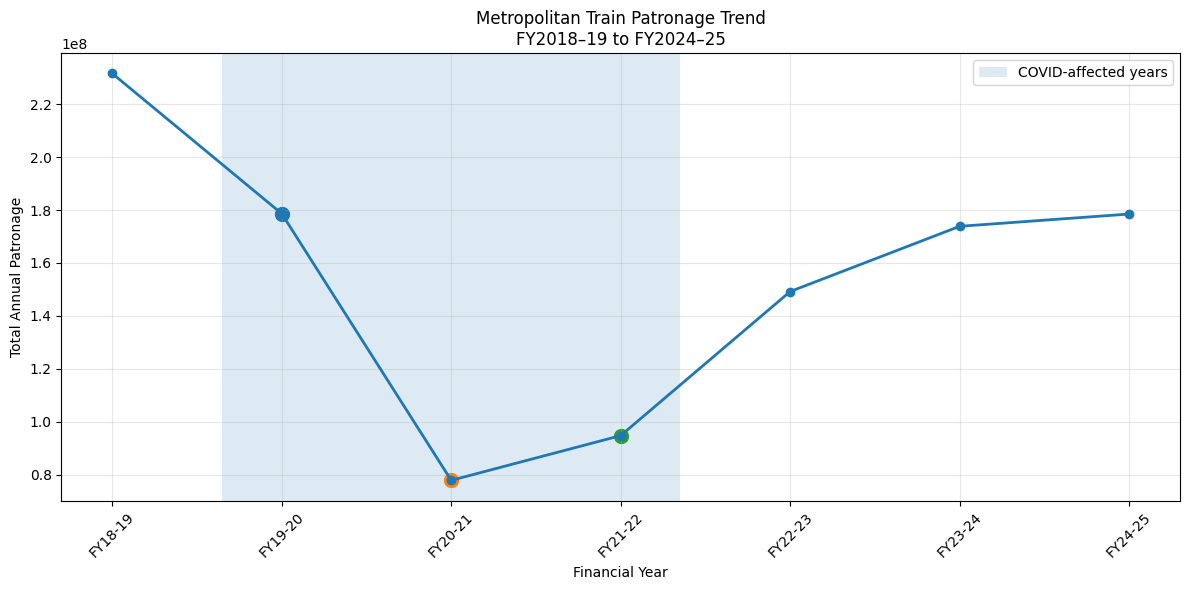

In [76]:
x = np.arange(
    len(metro_network)
)

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    metro_network["Pax_annual"],
    marker="o",
    linewidth=2
)

# COVID-affected financial years
covid_years = [
    "FY19-20",
    "FY20-21",
    "FY21-22"
]

covid_positions = [
    i
    for i, year
    in enumerate(
        metro_network["Fin_year"]
    )
    if year in covid_years
]

if covid_positions:

    plt.axvspan(
        min(covid_positions) - 0.35,
        max(covid_positions) + 0.35,
        alpha=0.15,
        label="COVID-affected years"
    )

    for pos in covid_positions:
        plt.scatter(
            pos,
            metro_network.loc[
                pos,
                "Pax_annual"
            ],
            s=100
        )

plt.xticks(
    x,
    metro_network["Fin_year"],
    rotation=45
)

plt.title(
    "Metropolitan Train Patronage Trend\n"
    "FY2018–19 to FY2024–25"
)

plt.xlabel("Financial Year")
plt.ylabel("Total Annual Patronage")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
metro_network[
    "Annual_change_%"
] = (
    metro_network["Pax_annual"]
    .pct_change()
    * 100
)

display(
    metro_network[
        [
            "Fin_year",
            "Pax_annual",
            "Annual_change_%"
        ]
    ].round(2)
)

,Fin_year,Pax_annual,Annual_change_%
0,FY18-19,231607950,NaN
1,FY19-20,178626800,-22.88
2,FY20-21,77820000,-56.43
3,FY21-22,94736800,21.74
4,FY22-23,149195750,57.48
5,FY23-24,173839400,16.52
6,FY24-25,178480700,2.67


In [78]:
pre_covid_year = "FY18-19"
latest_year = "FY24-25"

pre_covid_value = (
    metro_network.loc[
        metro_network["Fin_year"]
        == pre_covid_year,
        "Pax_annual"
    ].iloc[0]
)

covid_data = (
    metro_network[
        metro_network["Fin_year"]
        .isin(covid_years)
    ]
)

trough_row = (
    covid_data.loc[
        covid_data["Pax_annual"]
        .idxmin()
    ]
)

trough_year = (
    trough_row["Fin_year"]
)

trough_value = (
    trough_row["Pax_annual"]
)

latest_value = (
    metro_network.loc[
        metro_network["Fin_year"]
        == latest_year,
        "Pax_annual"
    ].iloc[0]
)

covid_decline = (
    (trough_value - pre_covid_value)
    / pre_covid_value
    * 100
)

recovery_from_trough = (
    (latest_value - trough_value)
    / trough_value
    * 100
)

latest_vs_pre_covid = (
    (latest_value - pre_covid_value)
    / pre_covid_value
    * 100
)

print(
    f"Pre-COVID baseline ({pre_covid_year}): "
    f"{pre_covid_value:,.0f}"
)

print(
    f"COVID-period trough ({trough_year}): "
    f"{trough_value:,.0f}"
)

print(
    f"Decline from pre-COVID baseline: "
    f"{covid_decline:.2f}%"
)

print(
    f"FY24-25 patronage: "
    f"{latest_value:,.0f}"
)

print(
    f"Recovery from trough to FY24-25: "
    f"{recovery_from_trough:.2f}%"
)

print(
    f"FY24-25 compared with FY18-19: "
    f"{latest_vs_pre_covid:.2f}%"
)

Pre-COVID baseline (FY18-19): 231,607,950
COVID-period trough (FY20-21): 77,820,000
Decline from pre-COVID baseline: -66.40%
FY24-25 patronage: 178,480,700
Recovery from trough to FY24-25: 129.35%
FY24-25 compared with FY18-19: -22.94%


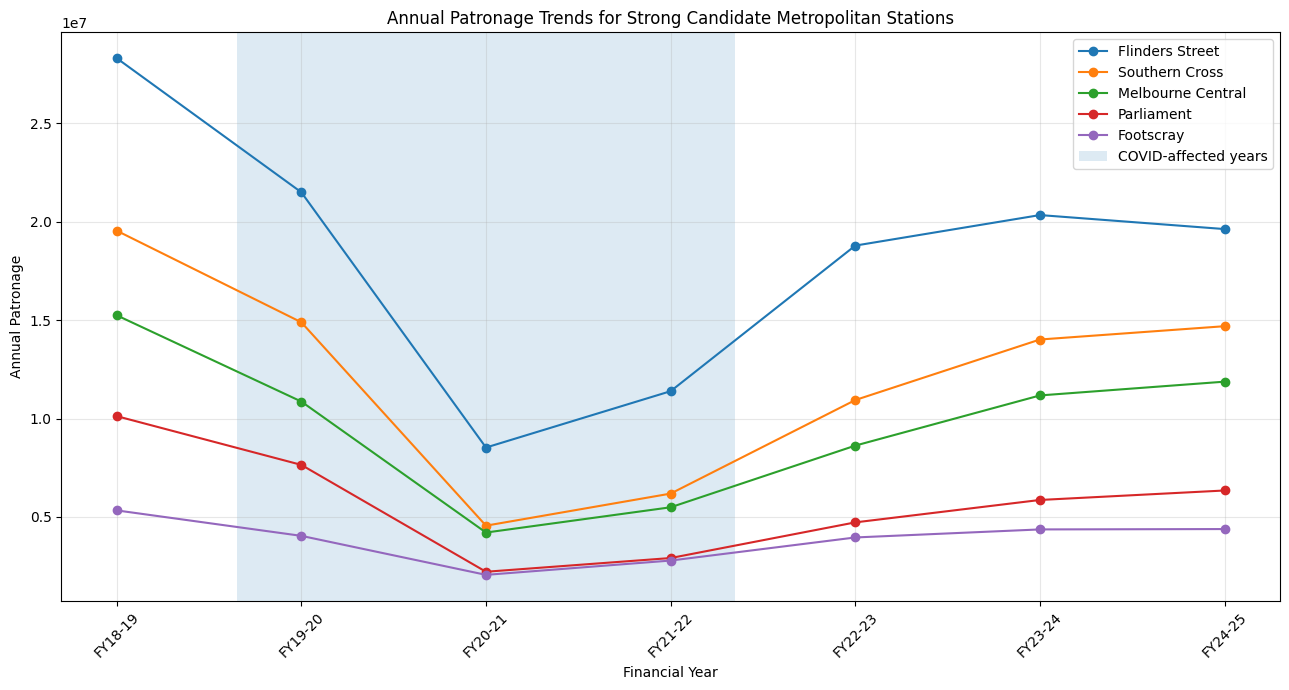

In [79]:
candidate_data = (
    metro[
        metro["Stop_ID"]
        .isin(candidate_ids)
    ]
    .copy()
)

plt.figure(figsize=(13, 7))

for stop_id in candidate_ids:

    station_data = (
        candidate_data[
            candidate_data["Stop_ID"]
            == stop_id
        ]
        .sort_values("Year_order")
    )

    station_name = (
        candidate_table.loc[
            candidate_table["Stop_ID"]
            == stop_id,
            "Stop_name"
        ].iloc[0]
    )

    plt.plot(
        station_data["Year_order"],
        station_data["Pax_annual"],
        marker="o",
        label=station_name
    )

plt.axvspan(
    1 - 0.35,
    3 + 0.35,
    alpha=0.15,
    label="COVID-affected years"
)

plt.xticks(
    range(len(YEAR_ORDER)),
    YEAR_ORDER,
    rotation=45
)

plt.title(
    "Annual Patronage Trends for "
    "Strong Candidate Metropolitan Stations"
)

plt.xlabel("Financial Year")
plt.ylabel("Annual Patronage")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

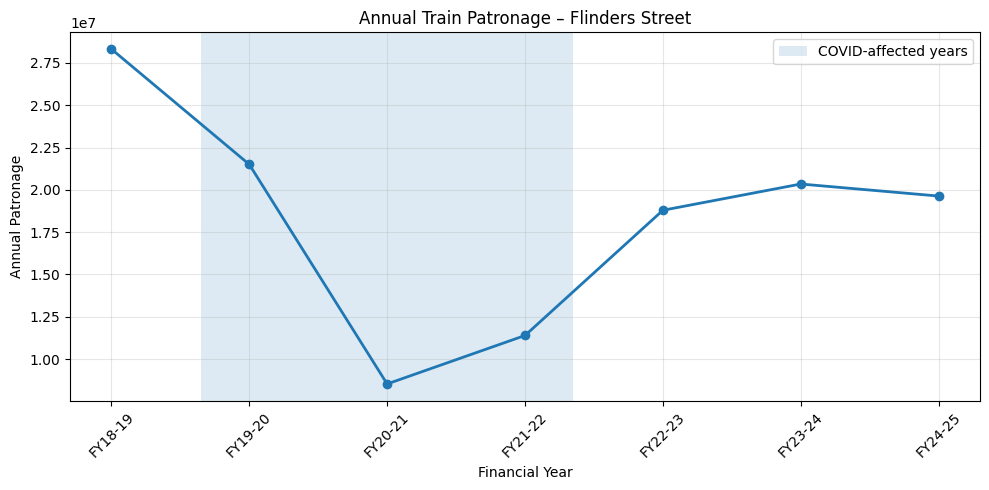

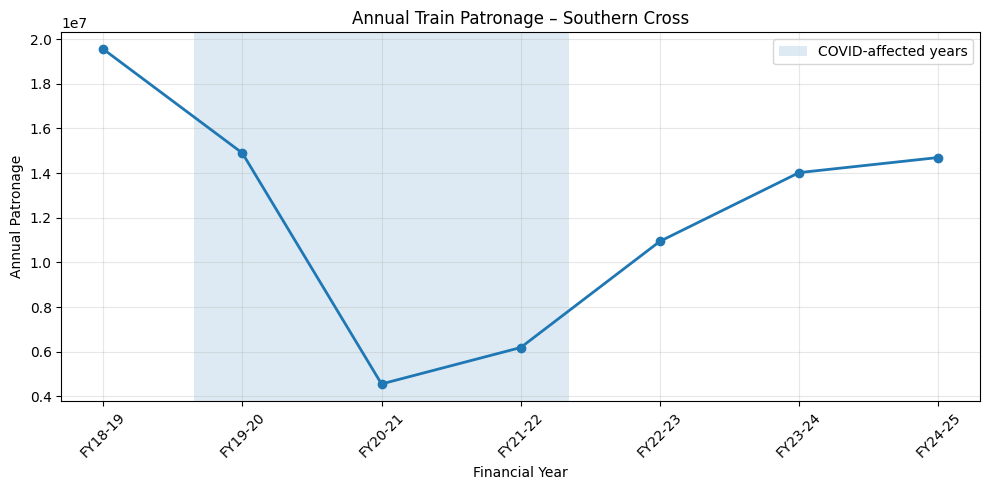

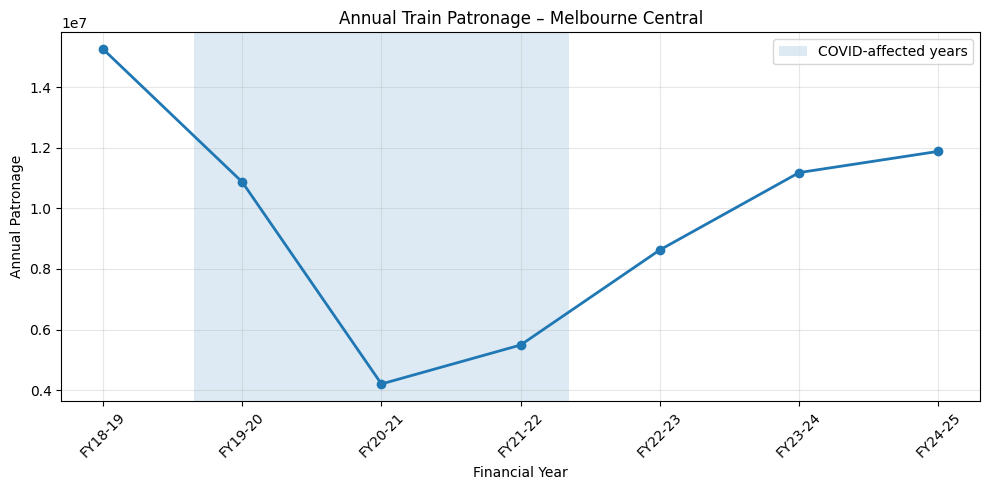

In [80]:
top_three_ids = candidate_ids[:3]

for stop_id in top_three_ids:

    station_data = (
        metro[
            metro["Stop_ID"]
            == stop_id
        ]
        .sort_values("Year_order")
    )

    station_name = (
        candidate_table.loc[
            candidate_table["Stop_ID"]
            == stop_id,
            "Stop_name"
        ].iloc[0]
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        station_data["Year_order"],
        station_data["Pax_annual"],
        marker="o",
        linewidth=2
    )

    plt.axvspan(
        1 - 0.35,
        3 + 0.35,
        alpha=0.15,
        label="COVID-affected years"
    )

    plt.xticks(
        range(len(YEAR_ORDER)),
        YEAR_ORDER,
        rotation=45
    )

    plt.title(
        f"Annual Train Patronage – "
        f"{station_name}"
    )

    plt.xlabel("Financial Year")
    plt.ylabel("Annual Patronage")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [82]:
station_changes = (
    candidate_data[
        [
            "Stop_ID",
            "Stop_name",
            "Fin_year",
            "Year_order",
            "Pax_annual"
        ]
    ]
    .sort_values(
        [
            "Stop_ID",
            "Year_order"
        ]
    )
)

station_changes[
    "Annual_change_%"
] = (
    station_changes
    .groupby("Stop_ID")[
        "Pax_annual"
    ]
    .pct_change()
    * 100
)

display(
    station_changes[
        [
            "Stop_name",
            "Fin_year",
            "Pax_annual",
            "Annual_change_%"
        ]
    ].round(2)
)

,Stop_name,Fin_year,Pax_annual,Annual_change_%
211,Melbourne Central,FY18-19,15250700,NaN
437,Melbourne Central,FY19-20,10865600,-28.75
658,Melbourne Central,FY20-21,4206700,-61.28
880,Melbourne Central,FY21-22,5491300,30.54
1099,Melbourne Central,FY22-23,8626300,57.09
1318,Melbourne Central,FY23-24,11176650,29.56
1350,Melbourne Central,FY24-25,11876900,6.27
212,Parliament,FY18-19,10124200,NaN
438,Parliament,FY19-20,7646300,-24.48
659,Parliament,FY20-21,2213650,-71.05


In [83]:
main_candidate_id = candidate_ids[0]

main_candidate_name = (
    candidate_table.loc[
        candidate_table["Stop_ID"]
        == main_candidate_id,
        "Stop_name"
    ].iloc[0]
)

station_data = (
    metro[
        metro["Stop_ID"]
        == main_candidate_id
    ][
        [
            "Fin_year",
            "Year_order",
            "Pax_annual"
        ]
    ]
    .sort_values("Year_order")
    .copy()
)

comparison = (
    station_data
    .merge(
        metro_network[
            [
                "Fin_year",
                "Pax_annual"
            ]
        ],
        on="Fin_year",
        suffixes=(
            "_station",
            "_network"
        )
    )
    .sort_values("Year_order")
)

station_baseline = (
    comparison[
        "Pax_annual_station"
    ].iloc[0]
)

network_baseline = (
    comparison[
        "Pax_annual_network"
    ].iloc[0]
)

comparison["Station_Index"] = (
    comparison[
        "Pax_annual_station"
    ]
    / station_baseline
    * 100
)

comparison["Network_Index"] = (
    comparison[
        "Pax_annual_network"
    ]
    / network_baseline
    * 100
)

display(
    comparison[
        [
            "Fin_year",
            "Pax_annual_station",
            "Station_Index",
            "Network_Index"
        ]
    ].round(2)
)

,Fin_year,Pax_annual_station,Station_Index,Network_Index
0,FY18-19,28320650,100.00,100.00
1,FY19-20,21503500,75.93,77.12
2,FY20-21,8528000,30.11,33.60
3,FY21-22,11392850,40.23,40.90
4,FY22-23,18793400,66.36,64.42
5,FY23-24,20345200,71.84,75.06
6,FY24-25,19633300,69.33,77.06


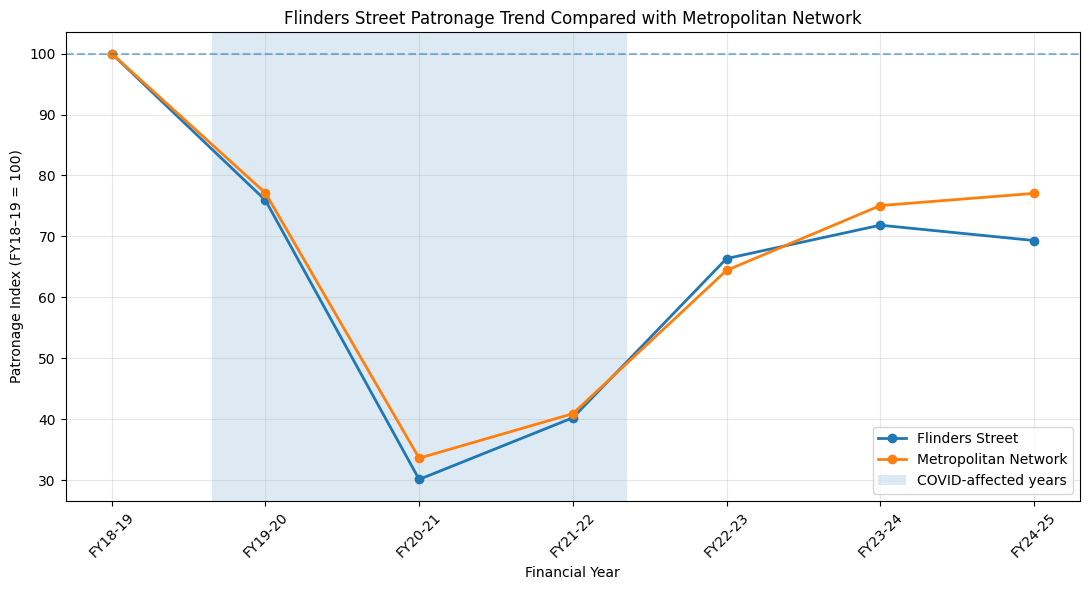

In [84]:
plt.figure(figsize=(11, 6))

plt.plot(
    comparison["Year_order"],
    comparison["Station_Index"],
    marker="o",
    linewidth=2,
    label=main_candidate_name
)

plt.plot(
    comparison["Year_order"],
    comparison["Network_Index"],
    marker="o",
    linewidth=2,
    label="Metropolitan Network"
)

plt.axhline(
    100,
    linestyle="--",
    alpha=0.5
)

plt.axvspan(
    1 - 0.35,
    3 + 0.35,
    alpha=0.15,
    label="COVID-affected years"
)

plt.xticks(
    range(len(YEAR_ORDER)),
    YEAR_ORDER,
    rotation=45
)

plt.title(
    f"{main_candidate_name} Patronage Trend "
    "Compared with Metropolitan Network"
)

plt.xlabel("Financial Year")
plt.ylabel(
    "Patronage Index "
    "(FY18–19 = 100)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

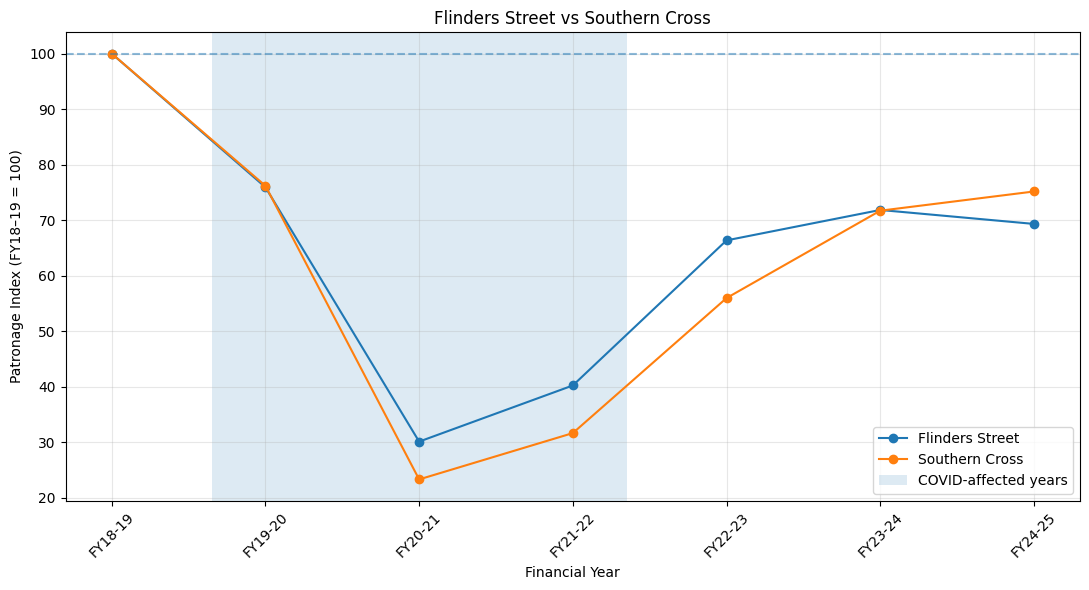

In [85]:
station1_id = candidate_ids[0]
station2_id = candidate_ids[1]

station1_name = (
    candidate_table.loc[
        candidate_table["Stop_ID"]
        == station1_id,
        "Stop_name"
    ].iloc[0]
)

station2_name = (
    candidate_table.loc[
        candidate_table["Stop_ID"]
        == station2_id,
        "Stop_name"
    ].iloc[0]
)


def station_index(df, stop_id):

    temp = (
        df[
            df["Stop_ID"] == stop_id
        ][
            [
                "Fin_year",
                "Year_order",
                "Pax_annual"
            ]
        ]
        .sort_values("Year_order")
        .copy()
    )

    baseline = (
        temp["Pax_annual"]
        .iloc[0]
    )

    temp["Index"] = (
        temp["Pax_annual"]
        / baseline
        * 100
    )

    return temp


s1 = station_index(
    metro,
    station1_id
)

s2 = station_index(
    metro,
    station2_id
)

plt.figure(figsize=(11, 6))

plt.plot(
    s1["Year_order"],
    s1["Index"],
    marker="o",
    label=station1_name
)

plt.plot(
    s2["Year_order"],
    s2["Index"],
    marker="o",
    label=station2_name
)

plt.axhline(
    100,
    linestyle="--",
    alpha=0.5
)

plt.axvspan(
    1 - 0.35,
    3 + 0.35,
    alpha=0.15,
    label="COVID-affected years"
)

plt.xticks(
    range(len(YEAR_ORDER)),
    YEAR_ORDER,
    rotation=45
)

plt.title(
    f"{station1_name} vs "
    f"{station2_name}"
)

plt.xlabel("Financial Year")
plt.ylabel(
    "Patronage Index "
    "(FY18–19 = 100)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
candidate_covid_summary = []

for stop_id in candidate_ids:

    temp = (
        metro[
            metro["Stop_ID"]
            == stop_id
        ]
        .sort_values("Year_order")
    )

    station_name = (
        candidate_table.loc[
            candidate_table["Stop_ID"]
            == stop_id,
            "Stop_name"
        ].iloc[0]
    )

    pre = (
        temp.loc[
            temp["Fin_year"]
            == "FY18-19",
            "Pax_annual"
        ]
    )

    covid = (
        temp[
            temp["Fin_year"]
            .isin(covid_years)
        ]
    )

    latest = (
        temp.loc[
            temp["Fin_year"]
            == "FY24-25",
            "Pax_annual"
        ]
    )

    if (
        len(pre) > 0
        and len(covid) > 0
        and len(latest) > 0
    ):

        pre_value = pre.iloc[0]

        trough_row = (
            covid.loc[
                covid["Pax_annual"]
                .idxmin()
            ]
        )

        trough_value = (
            trough_row["Pax_annual"]
        )

        trough_year = (
            trough_row["Fin_year"]
        )

        latest_value = (
            latest.iloc[0]
        )

        decline = (
            (trough_value - pre_value)
            / pre_value
            * 100
        )

        recovery = (
            (latest_value - trough_value)
            / trough_value
            * 100
        )

        latest_vs_pre = (
            (latest_value - pre_value)
            / pre_value
            * 100
        )

        candidate_covid_summary.append({
            "Station": station_name,
            "Pre_COVID_FY18-19":
                pre_value,
            "COVID_trough_year":
                trough_year,
            "COVID_trough_patronage":
                trough_value,
            "COVID_decline_%":
                decline,
            "Recovery_to_FY24-25_%":
                recovery,
            "FY24-25_vs_FY18-19_%":
                latest_vs_pre
        })


candidate_covid_summary = pd.DataFrame(
    candidate_covid_summary
)

display(
    candidate_covid_summary.round(2)
)

,Station,Pre_COVID_FY18-19,COVID_trough_year,COVID_trough_patronage,COVID_decline_%,Recovery_to_FY24-25_%,FY24-25_vs_FY18-19_%
0,Flinders Street,28320650,FY20-21,8528000,-69.89,130.22,-30.67
1,Southern Cross,19551450,FY20-21,4556450,-76.70,222.53,-24.83
2,Melbourne Central,15250700,FY20-21,4206700,-72.42,182.33,-22.12
3,Parliament,10124200,FY20-21,2213650,-78.14,186.61,-37.33
4,Footscray,5332950,FY20-21,2056000,-61.45,113.23,-17.80


In [87]:
print("=" * 70)
print("EVIDENCE-BASED OBSERVATIONS")
print("=" * 70)

print("\nOBSERVATION 1 — NETWORK COVID IMPACT")

print(
    f"The metropolitan network recorded "
    f"{pre_covid_value:,.0f} annual entries "
    f"in FY18-19."
)

print(
    f"Patronage reached its COVID-period "
    f"minimum in {trough_year} at "
    f"{trough_value:,.0f} entries."
)

print(
    f"This represents a decline of "
    f"{abs(covid_decline):.2f}% "
    f"from the FY18-19 baseline."
)

print(
    f"By FY24-25, patronage had changed by "
    f"{recovery_from_trough:.2f}% "
    f"from the COVID-period trough."
)


print("\nOBSERVATION 2 — DATA COMPLETENESS")

print(
    f"{len(complete_metro_stations)} "
    f"metropolitan stations have records "
    f"in all {total_metro_years} financial years."
)

print(
    f"The combined metropolitan dataset "
    f"contains {len(metro):,} station-year records."
)


print("\nOBSERVATION 3 — REGIONAL ROUNDING")

regional_multiple_50 = (
    (
        regional["Pax_annual"]
        .dropna()
        % 50
        == 0
    )
    .mean()
    * 100
)

print(
    f"{regional_multiple_50:.2f}% of regional "
    f"annual patronage values are multiples "
    f"of 50."
)

print(
    "This supports treating small regional "
    "patronage differences cautiously."
)


print("\nINITIAL CANDIDATE STATIONS")

for number, row in enumerate(
    candidate_table.itertuples(),
    start=1
):
    print(
        f"{number}. {row.Stop_name} — "
        f"{row.Years_available}/"
        f"{total_metro_years} years, "
        f"average patronage "
        f"{row.Average_patronage:,.0f}"
    )

EVIDENCE-BASED OBSERVATIONS

OBSERVATION 1 — NETWORK COVID IMPACT
The metropolitan network recorded 231,607,950 annual entries in FY18-19.
Patronage reached its COVID-period minimum in FY20-21 at 2,056,000 entries.
This represents a decline of 66.40% from the FY18-19 baseline.
By FY24-25, patronage had changed by 129.35% from the COVID-period trough.

OBSERVATION 2 — DATA COMPLETENESS
220 metropolitan stations have records in all 7 financial years.
The combined metropolitan dataset contains 1,555 station-year records.

OBSERVATION 3 — REGIONAL ROUNDING
100.00% of regional annual patronage values are multiples of 50.
This supports treating small regional patronage differences cautiously.

INITIAL CANDIDATE STATIONS
1. Flinders Street — 7/7 years, average patronage 18,359,557
2. Southern Cross — 7/7 years, average patronage 12,121,193
3. Melbourne Central — 7/7 years, average patronage 9,642,021
4. Parliament — 7/7 years, average patronage 5,689,557
5. Footscray — 7/7 years, average patr

In [88]:
summary = pd.DataFrame({
    "Measure": [
        "Financial years analysed",
        "Metro station-year records",
        "Regional station-year records",
        "Unique Metro stations",
        "Unique Regional stations",
        "Metro stations with complete 7-year coverage",
        "Metro duplicate station-year records",
        "Regional duplicate station-year records",
        "Metro ID/name conflicts",
        "Regional ID/name conflicts",
        "Regional values divisible by 50 (%)"
    ],

    "Result": [
        len(YEAR_ORDER),
        len(metro),
        len(regional),
        metro["Stop_ID"].nunique(),
        regional["Stop_ID"].nunique(),
        len(complete_metro_stations),
        int(
            metro_station_year_duplicates.sum()
        ),
        int(
            regional_station_year_duplicates.sum()
        ),
        len(metro_id_name_conflicts),
        len(regional_id_name_conflicts),
        round(
            regional_multiple_50,
            2
        )
    ]
})

display(summary)

,Measure,Result
0,Financial years analysed,7.0
1,Metro station-year records,1555.0
2,Regional station-year records,646.0
3,Unique Metro stations,224.0
4,Unique Regional stations,94.0
5,Metro stations with complete 7-year coverage,220.0
6,Metro duplicate station-year records,0.0
7,Regional duplicate station-year records,0.0
8,Metro ID/name conflicts,0.0
9,Regional ID/name conflicts,93.0
